## 🔹 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd

np.random.seed(13)

## 🔹Função Objetivo

In [2]:
# ======= Função objetivo (Rastrigin) =============
def rastrigin(x):
    n = len(x)
    return 10*n + sum(xi**2 - 10*np.cos(2*np.pi*xi) for xi in x)

## 🔹 Resolução 1 - Algoritmo DE (Differential Evolution)

In [3]:
# Parâmetros
n_vars = 10
lower, upper = -5.12, 5.12

pop_size = 100
max_evaluations = 100000

# Parâmetros fixos DE
F = 0.8
CR = 0.5
lambda_ = 0.9

# Função para plotar a população em 2D
def plot_population_2d(pop, generation=None, lower=-5.12, upper=5.12, resolution=100):
    clear_output(wait=True)  

    plt.figure(figsize=(6,6))

    x = np.linspace(lower, upper, resolution)
    y = np.linspace(lower, upper, resolution)
    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            vec = np.zeros(n_vars)
            vec[0] = X[i, j]
            vec[1] = Y[i, j]
            Z[i, j] = rastrigin(vec)

    # Preto e branco
    plt.contour(X, Y, Z, levels=25, colors='black', linewidths=0.5)

    plt.scatter(pop[:, 0], pop[:, 1], color='red', s=10, alpha=0.6)

    # Melhor indivíduo
    fitness_vals = np.array([rastrigin(ind) for ind in pop])
    best = pop[np.argmin(fitness_vals)]
    plt.scatter(best[0], best[1], facecolors='blue', s=15)

    if generation is not None:
        plt.title(f"DE - Geração {generation}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    plt.grid(True)

    plt.show()

# Inicialização
def init_population():
    return np.random.uniform(lower, upper, (pop_size, n_vars))

# Avaliação
def evaluate_population(pop):
    return np.array([rastrigin(ind) for ind in pop])

# Loop principal
def differential_evolution():  #DE/current-to-best/1/bin (com λ)
    pop = init_population()
    
    # Avaliação inicial
    fitness = evaluate_population(pop)
    total_evals = pop_size
    
    generation = 0

    best_history = []
    avg_history = []

    tol = 1e-3  

    print("Iniciando DE...")

    while total_evals < max_evaluations:

        best_fit = np.min(fitness)
        best_history.append(best_fit)
        avg_history.append(np.mean(fitness))

        if best_fit <= tol:
            print(f"Parada antecipada: atingiu tolerância (f <= {tol})")
            break

        new_pop = []
        new_fitness = []

        for i in range(pop_size):
            if total_evals >= max_evaluations:
                break

            # Seleção de índices
            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(idxs, 3, replace=False)

            # Mutação
            best = pop[np.argmin(fitness)]
            mutant = pop[i] + lambda_*(best - pop[i]) + F*(pop[r2] - pop[r3])
            mutant = np.clip(mutant, lower, upper)

            # Crossover
            trial = np.copy(pop[i])
            j_rand = np.random.randint(n_vars)

            for j in range(n_vars):
                if np.random.rand() < CR or j == j_rand:
                    trial[j] = mutant[j]

            # Avaliação
            trial_fit = rastrigin(trial)
            total_evals += 1

            if trial_fit <= tol:
                print(f"Parada antecipada dentro da geração {generation}")
                return best_history, avg_history, np.array([trial]), generation, True

            # Seleção
            if trial_fit <= fitness[i]:
                new_pop.append(trial)
                new_fitness.append(trial_fit)
            else:
                new_pop.append(pop[i])
                new_fitness.append(fitness[i])

        pop = np.array(new_pop)
        fitness = np.array(new_fitness)

        if generation % 50 == 0:
            print(f"Gen {generation} | Evals: {total_evals} | Best: {best_fit:.6f}")
            plot_population_2d(pop)
        generation += 1
    best_fit = np.min(fitness)
    return best_history, avg_history, pop, generation, best_fit <= tol

### 🔹 1.1 Execução e plot - DE 

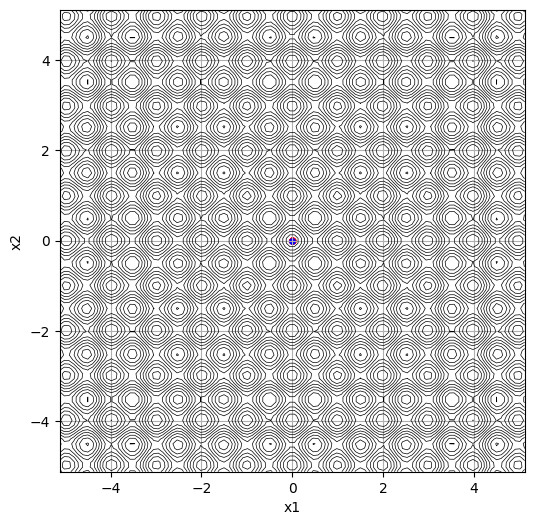

Parada antecipada dentro da geração 586

Tabela de Resultados:
   Execução  Convergiu  Gerações  Melhor f(x)
0         1       True       735     0.000764
1         2       True       559     0.000902
2         3       True       462     0.000840
3         4      False       999     0.994959
4         5       True       582     0.000842
5         6       True       536     0.000960
6         7       True       536     0.000578
7         8       True       497     0.000970
8         9       True       522     0.000400
9        10       True       586     0.000766

--- Estatísticas ---
Taxa de sucesso: 90.0%
Melhor valor: 0.000400
Média: 0.100198


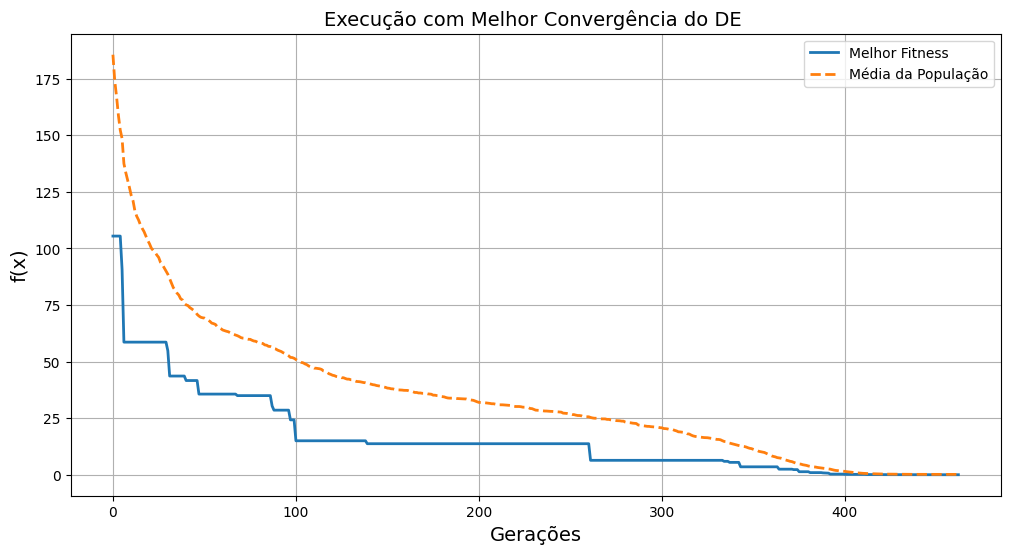

In [4]:
# loop de execuções
n_runs = 10
results = []
histories = []

for run in range(n_runs):
    print(f"\nExecução {run+1}/{n_runs}")

    best_hist, avg_hist, final_pop, n_gen, converged = differential_evolution()

    fitness_final = evaluate_population(final_pop)
    best_value = np.min(fitness_final)

    results.append({
        "Execução": run + 1,
        "Convergiu": converged,
        "Gerações": n_gen,
        "Melhor f(x)": best_value
    })

    histories.append({
        "best": best_hist,
        "avg": avg_hist,
        "gen": n_gen,
        "best_value": best_value,
        "converged": converged
    })

# tabela de resultados
df = pd.DataFrame(results)
print("\nTabela de Resultados:")
print(df)

# estatísticas
success_rate = df["Convergiu"].mean()
best_overall = df["Melhor f(x)"].min()
mean_value = df["Melhor f(x)"].mean()
print("\n--- Estatísticas ---")
print(f"Taxa de sucesso: {success_rate*100:.1f}%")
print(f"Melhor valor: {best_overall:.6f}")
print(f"Média: {mean_value:.6f}")

# Plot da melhor execução
valid_runs = [h for h in histories if h["converged"]]
if len(valid_runs) > 0:
    best_run = min(valid_runs, key=lambda x: x["gen"])
else:
    best_run = min(histories, key=lambda x: x["best_value"])
plt.figure(figsize=(12,6))
plt.plot(best_run["best"], label="Melhor Fitness",linewidth=2)
plt.plot(best_run["avg"], label="Média da População", linestyle='--', linewidth=2)

# plt.yscale('log') 
plt.xlabel("Gerações", fontsize=14)
plt.ylabel("f(x)", fontsize=14)
plt.title("Execução com Melhor Convergência do DE ", fontsize=14)
plt.legend()
plt.grid()

plt.show()

## 🔹2 Resolução com PSO (Particle Swarm Optimization)

In [ ]:
# Parâmetros
n_vars = 10
lower, upper = -5.12, 5.12

pop_size = 100
max_evaluations = 100000

# Parâmetros fixos PSO
w = 0.7
c1 = 2.0
c2 = 2.0



# Inicialização
def init_swarm():
    pos = np.random.uniform(lower, upper, (pop_size, n_vars))
    vel = np.random.uniform(-1, 1, (pop_size, n_vars))
    return pos, vel

# Avaliação
def evaluate_population(pop):
    return np.array([rastrigin(ind) for ind in pop])

# Loop principal
def pso():
    pos, vel = init_swarm()
    total_evals = 0
    generation = 0

    pbest = pos.copy()
    pbest_fit = evaluate_population(pos)

    gbest = pbest[np.argmin(pbest_fit)]

    best_history = []
    avg_history = []

    print("Iniciando PSO ...")

    while total_evals < max_evaluations:
        fitness = evaluate_population(pos)
        total_evals += pop_size

        # Atualiza pbest
        for i in range(pop_size):
            if fitness[i] < pbest_fit[i]:
                pbest[i] = pos[i]
                pbest_fit[i] = fitness[i]

        # Atualiza gbest
        gbest = pbest[np.argmin(pbest_fit)]

        best_history.append(np.min(fitness))
        avg_history.append(np.mean(fitness))

        # Atualiza velocidade e posição
        for i in range(pop_size):
            r1 = np.random.rand(n_vars)
            r2 = np.random.rand(n_vars)

            vel[i] = (
                w * vel[i]
                + c1 * r1 * (pbest[i] - pos[i])
                + c2 * r2 * (gbest - pos[i])
            )

            pos[i] += vel[i]
            pos[i] = np.clip(pos[i], lower, upper)

        if generation % 10 == 0:
            print(f"Gen {generation} | Best: {best_history[-1]:.4f}")

        generation += 1

    return best_history, avg_history, gbest



### 🔹 2.1 Execução e plot - PSO 

In [ ]:
## Execução
best_hist, avg_hist, best_x = pso()

print("\n--- FINAL PSO ---")
print(f"Melhor f(x): {rastrigin(best_x):.6f}")

## Plot
plt.figure(figsize=(10,5))
plt.plot(best_hist, label="Melhor")
plt.plot(avg_hist, label="Média")
plt.legend()
plt.grid()
plt.title("PSO - Convergência")
plt.show()